# 🏦 WealthWise — Investment Recommendation Model

## ML Pipeline: Ensemble Learning with Hyperparameter Tuning & Cross-Domain Generalization

**Objective**: Build a classification model that predicts the optimal investment category (Conservative / Balanced / Growth / Aggressive) based on a user's financial profile.

**Pipeline Overview**:
1. Synthetic Data Generation
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Base Model Training (Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM, KNN)
5. Ensemble Learning (Voting, Stacking, Bagging, Boosting)
6. Hyperparameter Tuning (GridSearchCV, RandomizedSearchCV)
7. Model Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
8. Cross-Domain Generalization
9. Model Export (Decision Rules for Web App)

---

## 1. Setup & Imports

In [ ]:
# Install required packages (run once)
!pip install -q scikit-learn xgboost pandas numpy matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('✅ XGBoost loaded successfully')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️ XGBoost not available, using GradientBoosting instead')

# Plot settings
plt.style.use('dark_background')
sns.set_palette('bright')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ All imports loaded successfully')
print(f'NumPy: {np.__version__}, Pandas: {pd.__version__}')

✅ XGBoost loaded successfully
✅ All imports loaded successfully
NumPy: 2.0.2, Pandas: 2.2.2


---
## 2. Synthetic Data Generation

We generate a realistic dataset of 5000 user financial profiles with features that influence investment risk decisions.

In [ ]:
def generate_investment_dataset(n_samples=5000, random_state=42):
    """
    Generate synthetic investment recommendation dataset.

    Features:
    - age: User's age (18-70)
    - monthly_income: Monthly income in INR
    - monthly_expenses: Monthly expenses in INR
    - savings_rate: % of income saved
    - existing_investments: Total existing investments in INR
    - risk_appetite: Self-reported risk tolerance (1-4)
    - investment_horizon: Years willing to invest
    - dependents: Number of dependents
    - debt_ratio: Debt-to-income ratio
    - financial_literacy: Financial knowledge score (1-10)

    Target: recommended_category (Conservative, Balanced, Growth, Aggressive)
    """
    rng = np.random.RandomState(random_state)

    # Generate features
    age = rng.randint(18, 71, n_samples)
    monthly_income = rng.choice(
        [15000, 25000, 35000, 50000, 75000, 100000, 150000, 200000],
        n_samples,
        p=[0.08, 0.15, 0.20, 0.22, 0.15, 0.10, 0.06, 0.04]
    ) + rng.randint(-5000, 5001, n_samples)
    monthly_income = np.clip(monthly_income, 10000, 250000)

    # Expenses correlated with income (50-90% of income)
    expense_ratio = rng.uniform(0.4, 0.85, n_samples)
    monthly_expenses = (monthly_income * expense_ratio).astype(int)

    savings_rate = ((monthly_income - monthly_expenses) / monthly_income * 100).round(1)
    savings_rate = np.clip(savings_rate, 0, 60)

    # Existing investments (correlated with age and income)
    base_invest = monthly_income * (age - 18) * 0.5
    existing_investments = (base_invest + rng.exponential(100000, n_samples)).astype(int)
    existing_investments = np.clip(existing_investments, 0, 10000000)

    # Risk appetite (1=conservative, 4=aggressive)
    # Younger people tend to be more risk-tolerant
    risk_base = np.where(age < 30, 3, np.where(age < 45, 2.5, np.where(age < 55, 2, 1.5)))
    risk_appetite = np.clip(np.round(risk_base + rng.normal(0, 0.8, n_samples)), 1, 4).astype(int)

    # Investment horizon (years)
    horizon_base = np.where(age < 30, 10, np.where(age < 45, 7, np.where(age < 55, 4, 2)))
    investment_horizon = np.clip(horizon_base + rng.randint(-2, 4, n_samples), 1, 20)

    dependents = rng.choice([0, 1, 2, 3, 4], n_samples, p=[0.25, 0.30, 0.25, 0.15, 0.05])

    debt_ratio = np.clip(rng.beta(2, 5, n_samples) * 0.8, 0, 0.7).round(2)

    # Financial literacy (1-10)
    literacy_base = np.where(monthly_income > 75000, 7, np.where(monthly_income > 40000, 5, 3))
    financial_literacy = np.clip(literacy_base + rng.randint(-2, 3, n_samples), 1, 10)

    # --- Generate Target Variable ---
    # Scoring system based on multiple features
    score = (
        risk_appetite * 2.8 +
        np.where(investment_horizon > 7, 3, np.where(investment_horizon > 3, 2, 1)) * 2.2 +
        financial_literacy * 0.3 +
        np.where(monthly_income > 75000, 2, np.where(monthly_income > 40000, 1, 0)) * 1.4 +
        np.where(savings_rate > 30, 2, np.where(savings_rate > 15, 1, 0)) * 1.2 +
        np.where(age < 35, 2, np.where(age < 50, 1, 0)) * 0.6 -
        dependents * 0.5 -
        debt_ratio * 3
    )

    # Add noise
    score += rng.normal(0, 1.5, n_samples)

    # Categorize
    categories = np.where(
        score < 8, 'Conservative',
        np.where(score < 12, 'Balanced',
        np.where(score < 16, 'Growth', 'Aggressive'))
    )

    # Create DataFrame
    df = pd.DataFrame({
        'age': age,
        'monthly_income': monthly_income,
        'monthly_expenses': monthly_expenses,
        'savings_rate': savings_rate,
        'existing_investments': existing_investments,
        'risk_appetite': risk_appetite,
        'investment_horizon': investment_horizon,
        'dependents': dependents,
        'debt_ratio': debt_ratio,
        'financial_literacy': financial_literacy,
        'recommended_category': categories
    })

    return df

# Generate dataset
df = generate_investment_dataset(5000)
print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['recommended_category'].value_counts())
df.head(10)

Dataset shape: (5000, 11)

Class distribution:
recommended_category
Aggressive      1955
Growth          1514
Balanced        1117
Conservative     414
Name: count, dtype: int64


,age,monthly_income,monthly_expenses,savings_rate,existing_investments,risk_appetite,investment_horizon,dependents,debt_ratio,financial_literacy,recommended_category
0,56,30493,17735,41.8,662976,1,1,0,0.13,5,Balanced
1,69,52042,30286,41.8,1329341,1,5,1,0.11,3,Balanced
2,46,195081,97898,49.8,3192518,1,6,3,0.11,5,Growth
3,32,16999,6932,59.2,200529,3,8,4,0.25,1,Aggressive
4,60,47970,31598,34.1,1010952,1,2,0,0.36,5,Conservative
5,25,20011,9917,50.4,159192,4,12,0,0.13,5,Aggressive
6,38,202824,100143,50.6,2085701,2,10,3,0.41,9,Aggressive
7,56,20761,9475,54.4,396892,1,3,1,0.25,5,Conservative
8,36,33185,16105,51.5,556932,4,10,3,0.40,1,Growth
9,40,70025,29011,58.6,771337,2,6,2,0.16,3,Growth


---
## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Dataset overview
print('='*60)
print('DATASET STATISTICS')
print('='*60)
print(f'\nTotal samples: {len(df)}')
print(f'Features: {df.shape[1] - 1}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nNumerical Summary:')
df.describe().round(2)

DATASET STATISTICS

Total samples: 5000
Features: 10
Missing values: 0

Numerical Summary:


,age,monthly_income,monthly_expenses,savings_rate,existing_investments,risk_appetite,investment_horizon,dependents,debt_ratio,financial_literacy
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,44.13,60162.66,37710.57,37.44,886554.36,2.26,6.18,1.43,0.23,4.65
std,15.21,43648.17,29087.56,12.83,811659.73,0.92,3.42,1.16,0.13,2.20
min,18.00,10011.00,4160.00,15.00,1158.00,1.00,1.00,0.00,0.00,1.00
25%,31.00,30672.50,18165.50,26.60,344865.50,2.00,3.00,0.00,0.13,3.00
50%,44.00,47528.50,28174.50,37.40,645764.00,2.00,6.00,1.00,0.21,5.00
75%,57.00,76068.25,48201.50,48.50,1139066.50,3.00,9.00,2.00,0.32,6.00
max,70.00,204708.00,171845.00,60.00,5424960.00,4.00,13.00,4.00,0.70,9.00


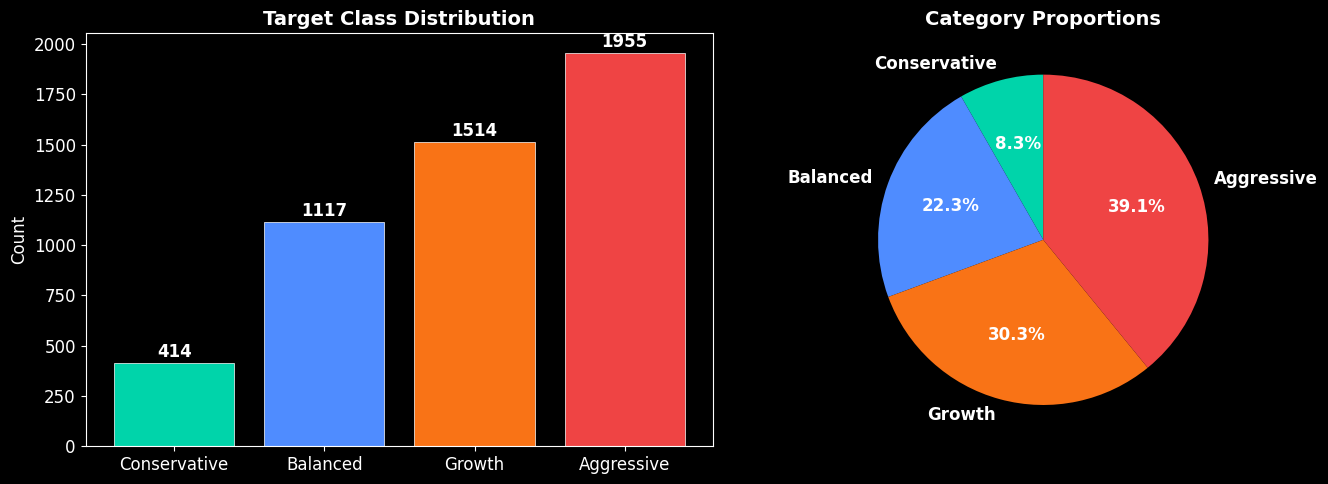

In [ ]:
# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#00d4aa', '#4f8cff', '#f97316', '#ef4444']
order = ['Conservative', 'Balanced', 'Growth', 'Aggressive']
counts = df['recommended_category'].value_counts().reindex(order)
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold', color='white')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'color': 'white', 'fontweight': 'bold'})
axes[1].set_title('Category Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

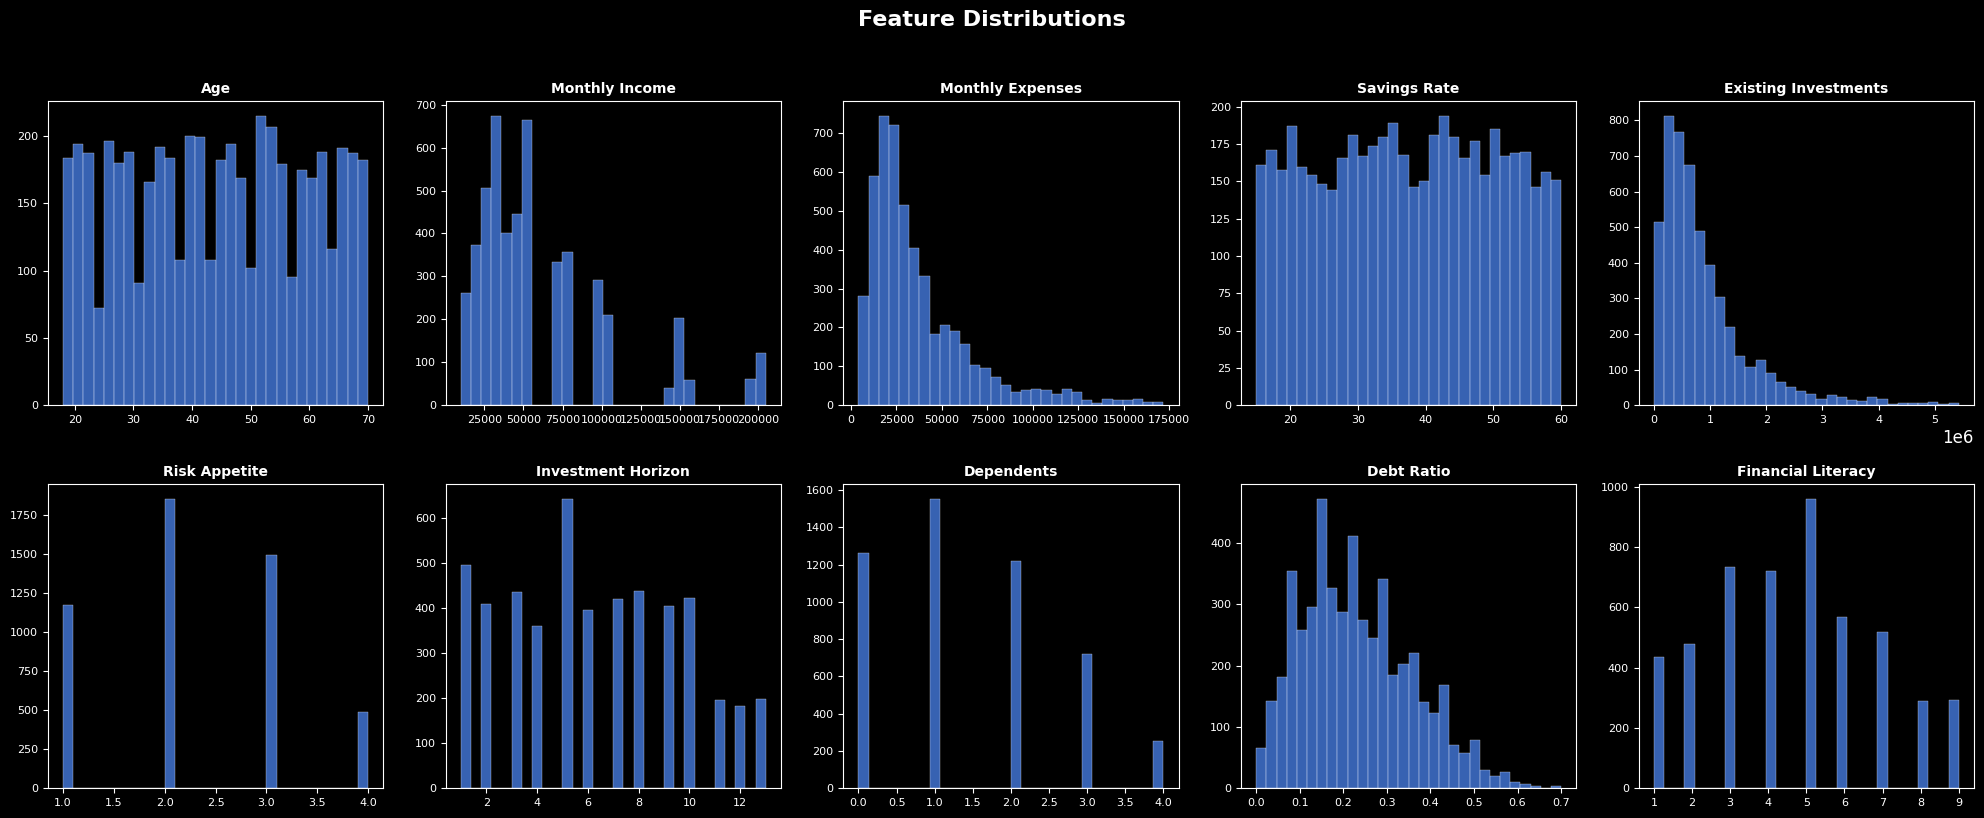

In [ ]:
# Feature Distributions
numerical_features = ['age', 'monthly_income', 'monthly_expenses', 'savings_rate',
                       'existing_investments', 'risk_appetite', 'investment_horizon',
                       'dependents', 'debt_ratio', 'financial_literacy']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].hist(df[feature], bins=30, color='#4f8cff', alpha=0.7, edgecolor='white', linewidth=0.3)
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

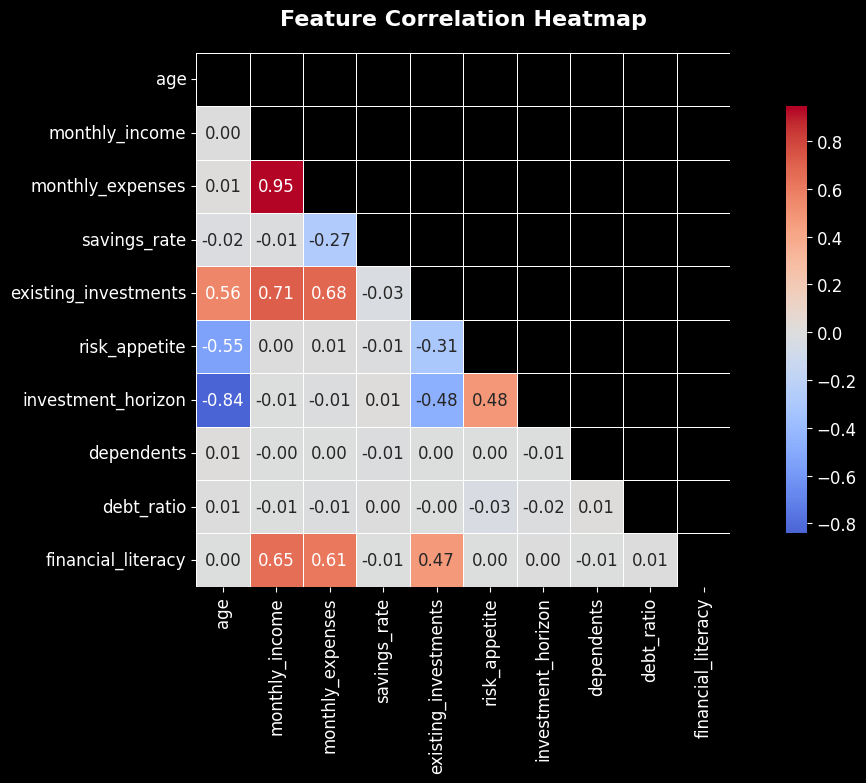

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df[numerical_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

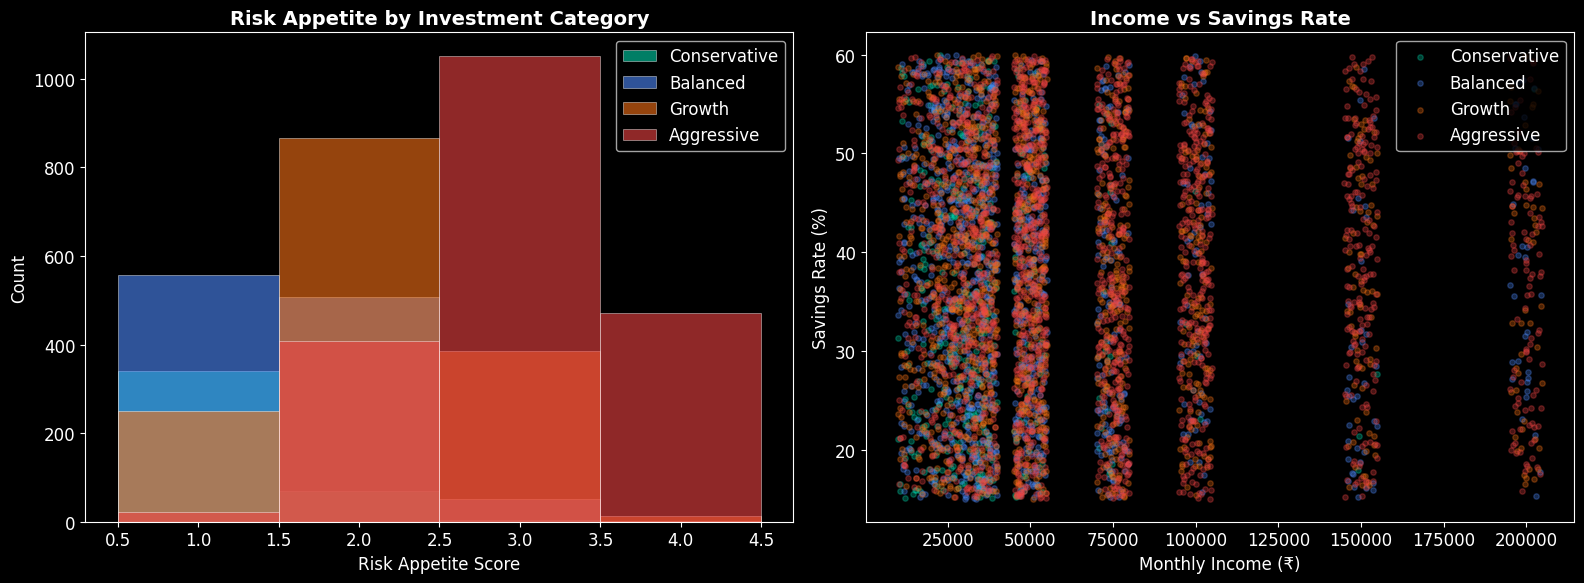

In [ ]:
# Risk Appetite vs Category + Income vs Savings Rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Risk appetite distribution per category
for cat, color in zip(order, colors):
    subset = df[df['recommended_category'] == cat]
    axes[0].hist(subset['risk_appetite'], bins=np.arange(0.5, 5.5, 1), alpha=0.6,
                 label=cat, color=color, edgecolor='white', linewidth=0.5)
axes[0].set_title('Risk Appetite by Investment Category', fontweight='bold')
axes[0].set_xlabel('Risk Appetite Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Income vs Savings Rate scatter
for cat, color in zip(order, colors):
    subset = df[df['recommended_category'] == cat]
    axes[1].scatter(subset['monthly_income'], subset['savings_rate'],
                    alpha=0.3, s=15, label=cat, color=color)
axes[1].set_title('Income vs Savings Rate', fontweight='bold')
axes[1].set_xlabel('Monthly Income (₹)')
axes[1].set_ylabel('Savings Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. Feature Engineering & Preprocessing

In [ ]:
# Create derived features
df['disposable_income'] = df['monthly_income'] - df['monthly_expenses']
df['savings_capacity'] = df['disposable_income'] / df['monthly_income']
df['risk_capacity_score'] = (
    df['risk_appetite'] * 0.3 +
    (df['investment_horizon'] / 20) * 0.25 +
    (df['financial_literacy'] / 10) * 0.2 +
    (1 - df['debt_ratio']) * 0.15 +
    df['savings_capacity'] * 0.1
)
df['income_per_dependent'] = df['monthly_income'] / (df['dependents'] + 1)
df['investment_income_ratio'] = df['existing_investments'] / (df['monthly_income'] * 12 + 1)

print(f'Dataset shape after feature engineering: {df.shape}')
print(f'\nNew features added:')
for feat in ['disposable_income', 'savings_capacity', 'risk_capacity_score',
             'income_per_dependent', 'investment_income_ratio']:
    print(f'  - {feat}: mean={df[feat].mean():.2f}, std={df[feat].std():.2f}')

Dataset shape after feature engineering: (5000, 16)

New features added:
  - disposable_income: mean=22452.09, std=18675.56
  - savings_capacity: mean=0.37, std=0.13
  - risk_capacity_score: mean=1.00, std=0.31
  - income_per_dependent: mean=32133.65, std=31196.00
  - investment_income_ratio: mean=1.30, std=0.70


In [ ]:
# Prepare features and target
feature_cols = [
    'age', 'monthly_income', 'monthly_expenses', 'savings_rate',
    'existing_investments', 'risk_appetite', 'investment_horizon',
    'dependents', 'debt_ratio', 'financial_literacy',
    'disposable_income', 'savings_capacity', 'risk_capacity_score',
    'income_per_dependent', 'investment_income_ratio'
]

X = df[feature_cols].copy()
y = df['recommended_category'].copy()

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Classes: {le.classes_}')
print(f'Encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Train-test split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTrain set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}')
print(f'Train class distribution: {np.bincount(y_train)}')
print(f'Test class distribution:  {np.bincount(y_test)}')

Classes: ['Aggressive' 'Balanced' 'Conservative' 'Growth']
Encoded: {'Aggressive': np.int64(0), 'Balanced': np.int64(1), 'Conservative': np.int64(2), 'Growth': np.int64(3)}

Train set: (4000, 15), Test set: (1000, 15)
Train class distribution: [1564  894  331 1211]
Test class distribution:  [391 223  83 303]


---
## 5. Base Model Training

In [ ]:
# Define base models
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, multi_class='multinomial'),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}

if XGBOOST_AVAILABLE:
    base_models['XGBoost'] = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=RANDOM_STATE, use_label_encoder=False,
        eval_metric='mlogloss', verbosity=0
    )
else:
    base_models['Gradient Boosting'] = GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE
    )

# Train and evaluate each base model
results = {}

print('='*80)
print(f'{"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
print('='*80)

for name, model in base_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'model': model,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'y_pred': y_pred
    }

    print(f'{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')

print('='*80)

Model                       Accuracy  Precision     Recall   F1-Score
Logistic Regression           0.7530     0.7600     0.7530     0.7549
Decision Tree                 0.7000     0.7004     0.7000     0.7000
Random Forest                 0.7480     0.7543     0.7480     0.7500
SVM                           0.7560     0.7632     0.7560     0.7571
KNN                           0.7020     0.7021     0.7020     0.7018
XGBoost                       0.7460     0.7533     0.7460     0.7483


In [ ]:
# Cross-validation for all base models (5-fold stratified)
print('\n' + '='*80)
print('5-FOLD STRATIFIED CROSS-VALIDATION RESULTS')
print('='*80)
print(f'{"Model":<25} {"Mean Accuracy":>15} {"Std Dev":>10}')
print('-'*50)

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model_info in results.items():
    model = model_info['model'].__class__(**model_info['model'].get_params())
    scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'{name:<25} {scores.mean():>15.4f} {scores.std():>10.4f}')

print('='*80)


5-FOLD STRATIFIED CROSS-VALIDATION RESULTS
Model                       Mean Accuracy    Std Dev
--------------------------------------------------
Logistic Regression                0.7355     0.0127
Decision Tree                      0.6855     0.0179
Random Forest                      0.7408     0.0107
SVM                                0.7413     0.0132
KNN                                0.6982     0.0050
XGBoost                            0.7340     0.0147


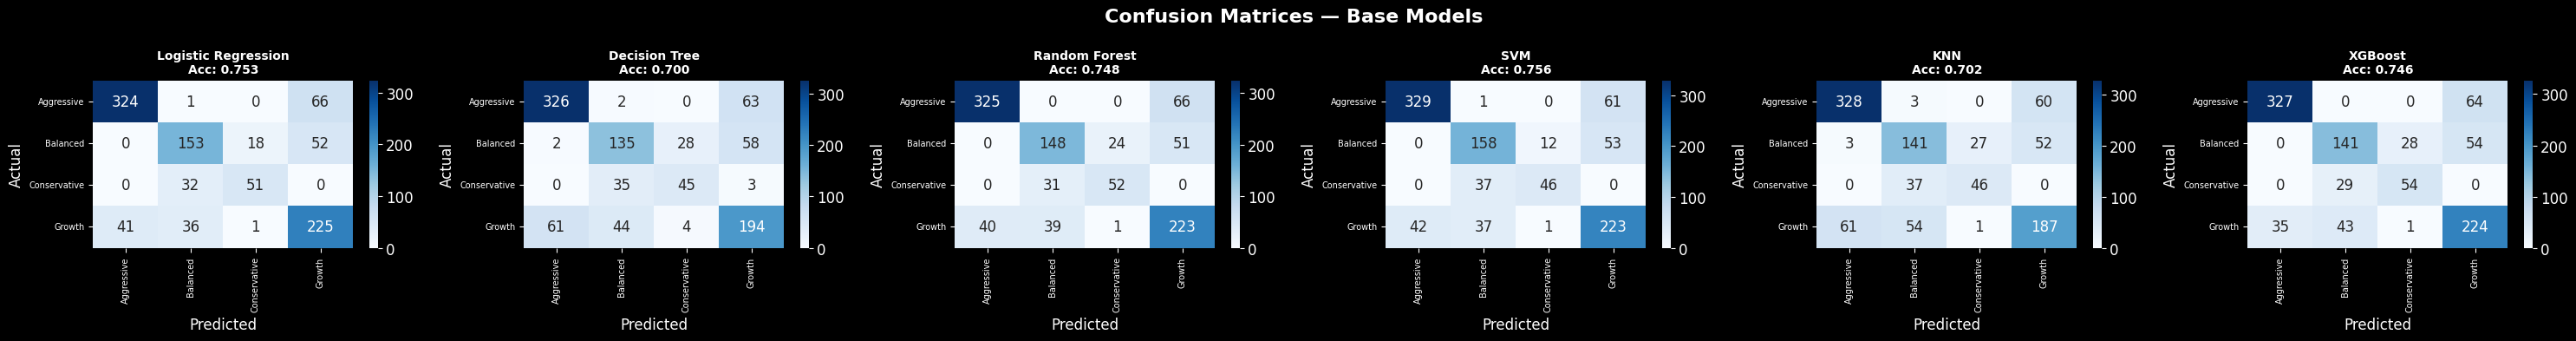

In [ ]:
# Confusion Matrices
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(labelsize=7)

plt.suptitle('Confusion Matrices — Base Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Ensemble Learning

In [ ]:
# --- Voting Classifier (Hard & Soft) ---
estimators_for_voting = [
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, multi_class='multinomial')),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
]

boosting_name = 'xgb' if XGBOOST_AVAILABLE else 'gb'
boosting_model = (XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                random_state=RANDOM_STATE, use_label_encoder=False,
                                eval_metric='mlogloss', verbosity=0)
                  if XGBOOST_AVAILABLE
                  else GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                  learning_rate=0.1, random_state=RANDOM_STATE))
estimators_for_voting.append((boosting_name, boosting_model))

# Hard Voting
hard_voting = VotingClassifier(estimators=estimators_for_voting, voting='hard', n_jobs=-1)
hard_voting.fit(X_train_scaled, y_train)
y_pred_hv = hard_voting.predict(X_test_scaled)
acc_hv = accuracy_score(y_test, y_pred_hv)

# Soft Voting
soft_voting = VotingClassifier(estimators=estimators_for_voting, voting='soft', n_jobs=-1)
soft_voting.fit(X_train_scaled, y_train)
y_pred_sv = soft_voting.predict(X_test_scaled)
acc_sv = accuracy_score(y_test, y_pred_sv)

print(f'Hard Voting Accuracy: {acc_hv:.4f}')
print(f'Soft Voting Accuracy: {acc_sv:.4f}')

Hard Voting Accuracy: 0.7580
Soft Voting Accuracy: 0.7550


In [ ]:
# --- Stacking Classifier ---
stacking_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
]

stacking_estimators.append((boosting_name, boosting_model.__class__(**boosting_model.get_params())))

stacking_clf = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

stacking_clf.fit(X_train_scaled, y_train)
y_pred_stack = stacking_clf.predict(X_test_scaled)
acc_stack = accuracy_score(y_test, y_pred_stack)
print(f'Stacking Classifier Accuracy: {acc_stack:.4f}')

Stacking Classifier Accuracy: 0.7580


In [ ]:
# --- Bagging Classifier ---
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
bagging_clf.fit(X_train_scaled, y_train)
y_pred_bag = bagging_clf.predict(X_test_scaled)
acc_bag = accuracy_score(y_test, y_pred_bag)
print(f'Bagging Classifier Accuracy: {acc_bag:.4f}')

Bagging Classifier Accuracy: 0.7550



ENSEMBLE MODEL COMPARISON
Method                 Accuracy   F1-Score
----------------------------------------
Hard Voting              0.7580     0.7593
Soft Voting              0.7550     0.7560
Stacking                 0.7580     0.7585
Bagging                  0.7550     0.7566


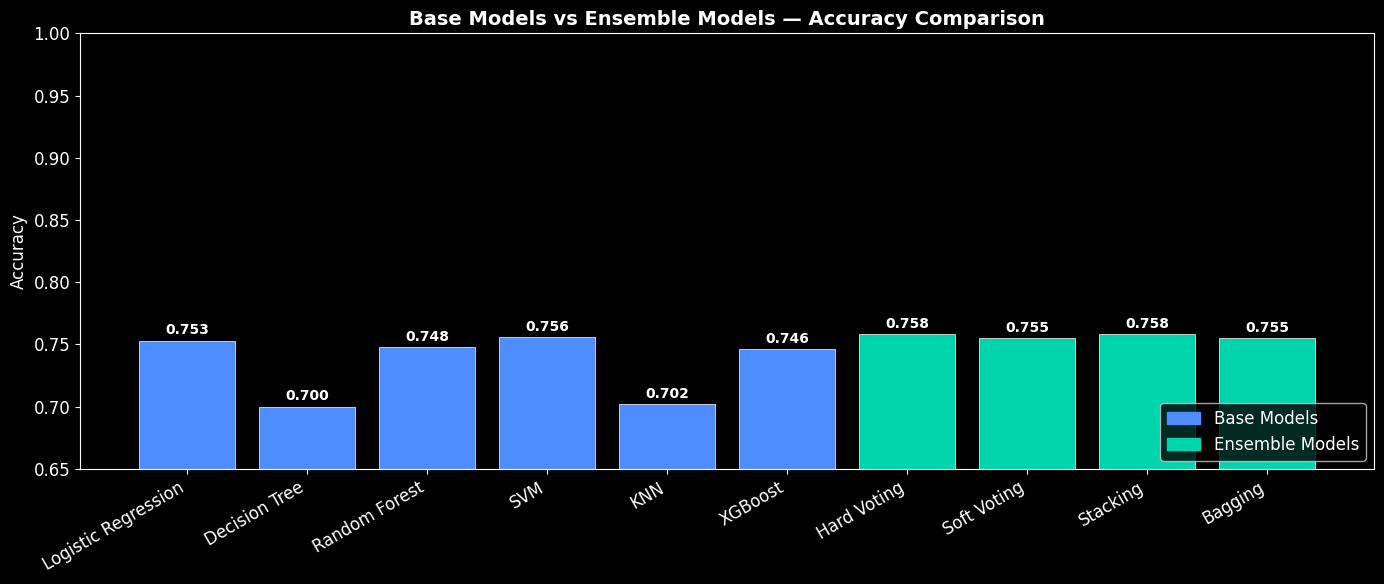

In [ ]:
# Ensemble Comparison
ensemble_results = {
    'Hard Voting': {'accuracy': acc_hv, 'y_pred': y_pred_hv},
    'Soft Voting': {'accuracy': acc_sv, 'y_pred': y_pred_sv},
    'Stacking': {'accuracy': acc_stack, 'y_pred': y_pred_stack},
    'Bagging': {'accuracy': acc_bag, 'y_pred': y_pred_bag}
}

print('\n' + '='*60)
print('ENSEMBLE MODEL COMPARISON')
print('='*60)
print(f'{"Method":<20} {"Accuracy":>10} {"F1-Score":>10}')
print('-'*40)

for name, res in ensemble_results.items():
    f1 = f1_score(y_test, res['y_pred'], average='weighted')
    res['f1'] = f1
    print(f'{name:<20} {res["accuracy"]:>10.4f} {f1:>10.4f}')

print('='*60)

# Plot comparison
all_models = {**{k: v['accuracy'] for k, v in results.items()},
              **{k: v['accuracy'] for k, v in ensemble_results.items()}}

fig, ax = plt.subplots(figsize=(14, 6))
names = list(all_models.keys())
accs = list(all_models.values())
colors_bar = ['#4f8cff'] * len(results) + ['#00d4aa'] * len(ensemble_results)

bars = ax.bar(names, accs, color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Accuracy')
ax.set_title('Base Models vs Ensemble Models — Accuracy Comparison', fontweight='bold', fontsize=14)
ax.set_ylim(min(accs) - 0.05, 1.0)
plt.xticks(rotation=30, ha='right')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', fontweight='bold', fontsize=10, color='white')

# Add legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4f8cff', label='Base Models'),
                    Patch(color='#00d4aa', label='Ensemble Models')],
          loc='lower right')

plt.tight_layout()
plt.show()

---
## 7. Hyperparameter Tuning

In [ ]:
# --- GridSearchCV for Random Forest ---
print('🔍 GridSearchCV — Random Forest')
print('-' * 40)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train_scaled, y_train)

print(f'Best parameters: {rf_grid.best_params_}')
print(f'Best CV accuracy: {rf_grid.best_score_:.4f}')

# Evaluate on test set
y_pred_rf_tuned = rf_grid.predict(X_test_scaled)
acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
print(f'Test accuracy: {acc_rf_tuned:.4f}')
print(f'Improvement over default RF: {(acc_rf_tuned - results["Random Forest"]["accuracy"])*100:+.2f}%')

🔍 GridSearchCV — Random Forest
----------------------------------------
Best parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV accuracy: 0.7502
Test accuracy: 0.7690
Improvement over default RF: +2.10%


In [ ]:
# --- RandomizedSearchCV for XGBoost / Gradient Boosting ---
boosting_label = 'XGBoost' if XGBOOST_AVAILABLE else 'Gradient Boosting'
print(f'🔍 RandomizedSearchCV — {boosting_label}')
print('-' * 40)

if XGBOOST_AVAILABLE:
    xgb_param_dist = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [4, 6, 8, 10, 12],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5, 7],
        'gamma': [0, 0.1, 0.2, 0.3]
    }
    base_est = XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False,
                             eval_metric='mlogloss', verbosity=0)
else:
    xgb_param_dist = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_est = GradientBoostingClassifier(random_state=RANDOM_STATE)

xgb_random = RandomizedSearchCV(
    base_est,
    xgb_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

xgb_random.fit(X_train_scaled, y_train)

print(f'Best parameters: {xgb_random.best_params_}')
print(f'Best CV accuracy: {xgb_random.best_score_:.4f}')

y_pred_xgb_tuned = xgb_random.predict(X_test_scaled)
acc_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
original_key = 'XGBoost' if XGBOOST_AVAILABLE else 'Gradient Boosting'
print(f'Test accuracy: {acc_xgb_tuned:.4f}')
print(f'Improvement over default: {(acc_xgb_tuned - results[original_key]["accuracy"])*100:+.2f}%')

🔍 RandomizedSearchCV — XGBoost
----------------------------------------
Best parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.9}
Best CV accuracy: 0.7518
Test accuracy: 0.7710
Improvement over default: +2.50%


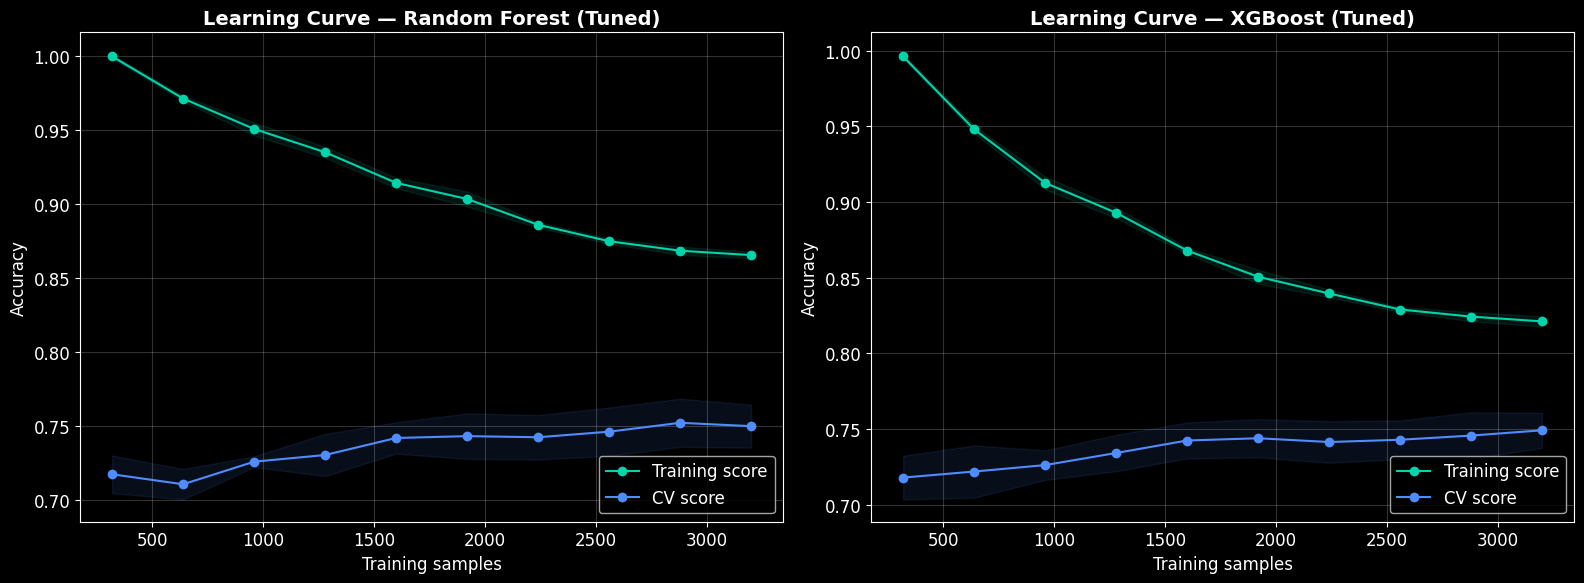

In [ ]:
# --- Learning Curves ---
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model, title) in zip(axes, [
    (rf_grid.best_estimator_, 'Random Forest (Tuned)'),
    (xgb_random.best_estimator_, f'{boosting_label} (Tuned)')
]):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#00d4aa')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#4f8cff')
    ax.plot(train_sizes, train_mean, 'o-', color='#00d4aa', label='Training score')
    ax.plot(train_sizes, val_mean, 'o-', color='#4f8cff', label='CV score')
    ax.set_title(f'Learning Curve — {title}', fontweight='bold')
    ax.set_xlabel('Training samples')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
## 8. Final Model Evaluation

In [ ]:
# Build final tuned ensemble
final_estimators = [
    ('rf', rf_grid.best_estimator_),
    ('boost', xgb_random.best_estimator_),
    ('svm', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
]

final_ensemble = VotingClassifier(estimators=final_estimators, voting='soft', n_jobs=-1)
final_ensemble.fit(X_train_scaled, y_train)

y_pred_final = final_ensemble.predict(X_test_scaled)
acc_final = accuracy_score(y_test, y_pred_final)

print('='*60)
print('FINAL TUNED ENSEMBLE MODEL RESULTS')
print('='*60)
print(f'\nAccuracy:  {acc_final:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_final, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_final, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_final, average="weighted"):.4f}')

# ROC-AUC (one-vs-rest)
try:
    y_prob_final = final_ensemble.predict_proba(X_test_scaled)
    roc_auc = roc_auc_score(y_test, y_prob_final, multi_class='ovr', average='weighted')
    print(f'ROC-AUC:   {roc_auc:.4f}')
except Exception as e:
    print(f'ROC-AUC:   N/A ({e})')

print(f'\n--- Classification Report ---')
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

FINAL TUNED ENSEMBLE MODEL RESULTS

Accuracy:  0.7620
Precision: 0.7687
Recall:    0.7620
F1-Score:  0.7632
ROC-AUC:   0.9291

--- Classification Report ---
              precision    recall  f1-score   support

  Aggressive       0.89      0.85      0.87       391
    Balanced       0.69      0.70      0.69       223
Conservative       0.77      0.58      0.66        83
      Growth       0.67      0.75      0.70       303

    accuracy                           0.76      1000
   macro avg       0.76      0.72      0.73      1000
weighted avg       0.77      0.76      0.76      1000



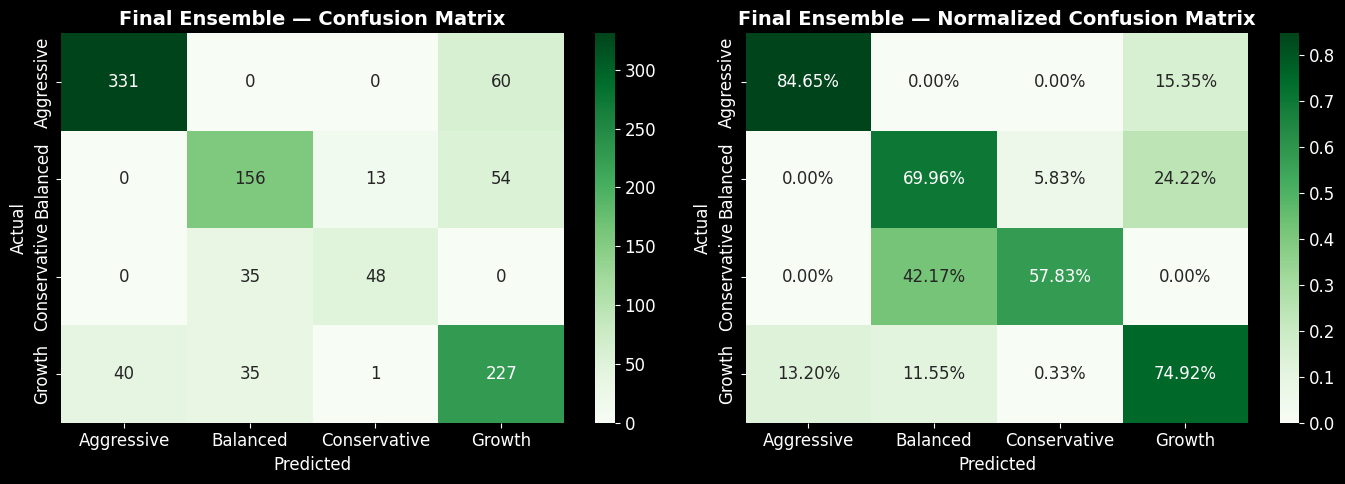

In [ ]:
# Final Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('Final Ensemble — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Final Ensemble — Normalized Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

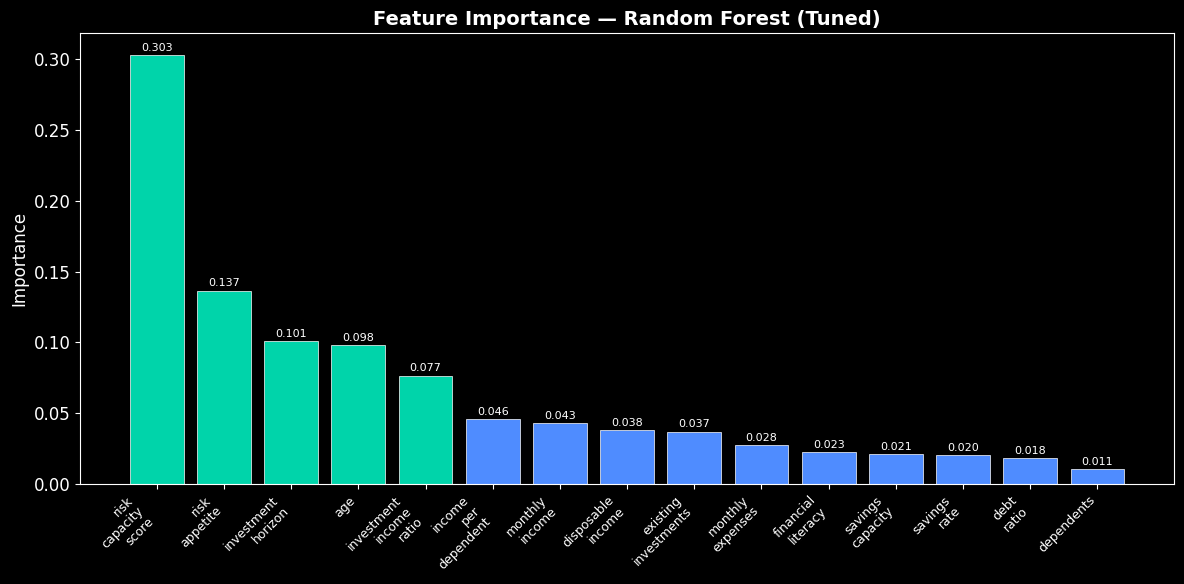


Top 5 Most Important Features:
  1. risk_capacity_score: 0.3032
  2. risk_appetite: 0.1367
  3. investment_horizon: 0.1008
  4. age: 0.0983
  5. investment_income_ratio: 0.0766


In [ ]:
# Feature Importance (Random Forest)
rf_best = rf_grid.best_estimator_
importances = rf_best.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(feature_cols)), importances[sorted_idx],
              color=['#00d4aa' if i < 5 else '#4f8cff' for i in range(len(feature_cols))],
              edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([feature_cols[i].replace('_', '\n') for i in sorted_idx], fontsize=9, rotation=45, ha='right')
ax.set_title('Feature Importance — Random Forest (Tuned)', fontweight='bold', fontsize=14)
ax.set_ylabel('Importance')

for bar, imp in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{imp:.3f}', ha='center', fontsize=8, color='white')

plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
for i in range(5):
    print(f'  {i+1}. {feature_cols[sorted_idx[i]]}: {importances[sorted_idx[i]]:.4f}')

---
## 9. Cross-Domain Generalization

Test how well the model generalizes across different user demographics and financial profiles.

In [ ]:
# --- Domain 1: Age-Group Generalization ---
print('='*60)
print('CROSS-DOMAIN GENERALIZATION: AGE GROUPS')
print('='*60)

age_groups = {
    'Young (18-30)': (18, 30),
    'Middle (31-45)': (31, 45),
    'Senior (46-70)': (46, 70)
}

age_results = {}

for train_group, (train_min, train_max) in age_groups.items():
    # Train on one age group, test on others
    train_mask = (df['age'] >= train_min) & (df['age'] <= train_max)
    test_mask = ~train_mask

    X_domain_train = scaler.fit_transform(df.loc[train_mask, feature_cols])
    y_domain_train = le.transform(df.loc[train_mask, 'recommended_category'])
    X_domain_test = scaler.transform(df.loc[test_mask, feature_cols])
    y_domain_test = le.transform(df.loc[test_mask, 'recommended_category'])

    model_cd = RandomForestClassifier(**rf_grid.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
    model_cd.fit(X_domain_train, y_domain_train)
    y_pred_cd = model_cd.predict(X_domain_test)

    acc_cd = accuracy_score(y_domain_test, y_pred_cd)
    f1_cd = f1_score(y_domain_test, y_pred_cd, average='weighted')
    age_results[train_group] = {'accuracy': acc_cd, 'f1': f1_cd}

    print(f'Train on {train_group}, Test on rest → Accuracy: {acc_cd:.4f}, F1: {f1_cd:.4f}')

print()

CROSS-DOMAIN GENERALIZATION: AGE GROUPS
Train on Young (18-30), Test on rest → Accuracy: 0.4264, F1: 0.3393
Train on Middle (31-45), Test on rest → Accuracy: 0.6459, F1: 0.6083
Train on Senior (46-70), Test on rest → Accuracy: 0.6982, F1: 0.7201



In [ ]:
# --- Domain 2: Income-Bracket Generalization ---
print('='*60)
print('CROSS-DOMAIN GENERALIZATION: INCOME BRACKETS')
print('='*60)

income_groups = {
    'Low Income (<30K)': (0, 30000),
    'Mid Income (30K-75K)': (30000, 75000),
    'High Income (>75K)': (75000, 300000)
}

income_results = {}

for train_group, (train_min, train_max) in income_groups.items():
    train_mask = (df['monthly_income'] >= train_min) & (df['monthly_income'] < train_max)
    test_mask = ~train_mask

    if train_mask.sum() < 50 or test_mask.sum() < 50:
        continue

    X_domain_train = scaler.fit_transform(df.loc[train_mask, feature_cols])
    y_domain_train = le.transform(df.loc[train_mask, 'recommended_category'])
    X_domain_test = scaler.transform(df.loc[test_mask, feature_cols])
    y_domain_test = le.transform(df.loc[test_mask, 'recommended_category'])

    model_cd = RandomForestClassifier(**rf_grid.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
    model_cd.fit(X_domain_train, y_domain_train)
    y_pred_cd = model_cd.predict(X_domain_test)

    acc_cd = accuracy_score(y_domain_test, y_pred_cd)
    f1_cd = f1_score(y_domain_test, y_pred_cd, average='weighted')
    income_results[train_group] = {'accuracy': acc_cd, 'f1': f1_cd}

    print(f'Train on {train_group}, Test on rest → Accuracy: {acc_cd:.4f}, F1: {f1_cd:.4f}')

print()

CROSS-DOMAIN GENERALIZATION: INCOME BRACKETS
Train on Low Income (<30K), Test on rest → Accuracy: 0.6353, F1: 0.6380
Train on Mid Income (30K-75K), Test on rest → Accuracy: 0.7282, F1: 0.7365
Train on High Income (>75K), Test on rest → Accuracy: 0.5244, F1: 0.4632



In [ ]:
# --- Domain 3: Geographic Simulation (Expense Pattern Variation) ---
print('='*60)
print('CROSS-DOMAIN GENERALIZATION: GEOGRAPHIC (EXPENSE PATTERNS)')
print('='*60)

# Simulate metro vs non-metro by expense ratio
median_expense_ratio = (df['monthly_expenses'] / df['monthly_income']).median()

expense_ratio = df['monthly_expenses'] / df['monthly_income']
metro_mask = expense_ratio > median_expense_ratio  # Higher expenses = metro simulation
non_metro_mask = ~metro_mask

geo_results = {}

for label, train_mask, test_mask in [
    ('Train Metro, Test Non-Metro', metro_mask, non_metro_mask),
    ('Train Non-Metro, Test Metro', non_metro_mask, metro_mask)
]:
    X_geo_train = scaler.fit_transform(df.loc[train_mask, feature_cols])
    y_geo_train = le.transform(df.loc[train_mask, 'recommended_category'])
    X_geo_test = scaler.transform(df.loc[test_mask, feature_cols])
    y_geo_test = le.transform(df.loc[test_mask, 'recommended_category'])

    model_geo = RandomForestClassifier(**rf_grid.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
    model_geo.fit(X_geo_train, y_geo_train)
    y_pred_geo = model_geo.predict(X_geo_test)

    acc_geo = accuracy_score(y_geo_test, y_pred_geo)
    f1_geo = f1_score(y_geo_test, y_pred_geo, average='weighted')
    geo_results[label] = {'accuracy': acc_geo, 'f1': f1_geo}

    print(f'{label} → Accuracy: {acc_geo:.4f}, F1: {f1_geo:.4f}')

CROSS-DOMAIN GENERALIZATION: GEOGRAPHIC (EXPENSE PATTERNS)
Train Metro, Test Non-Metro → Accuracy: 0.7452, F1: 0.7461
Train Non-Metro, Test Metro → Accuracy: 0.7236, F1: 0.7170


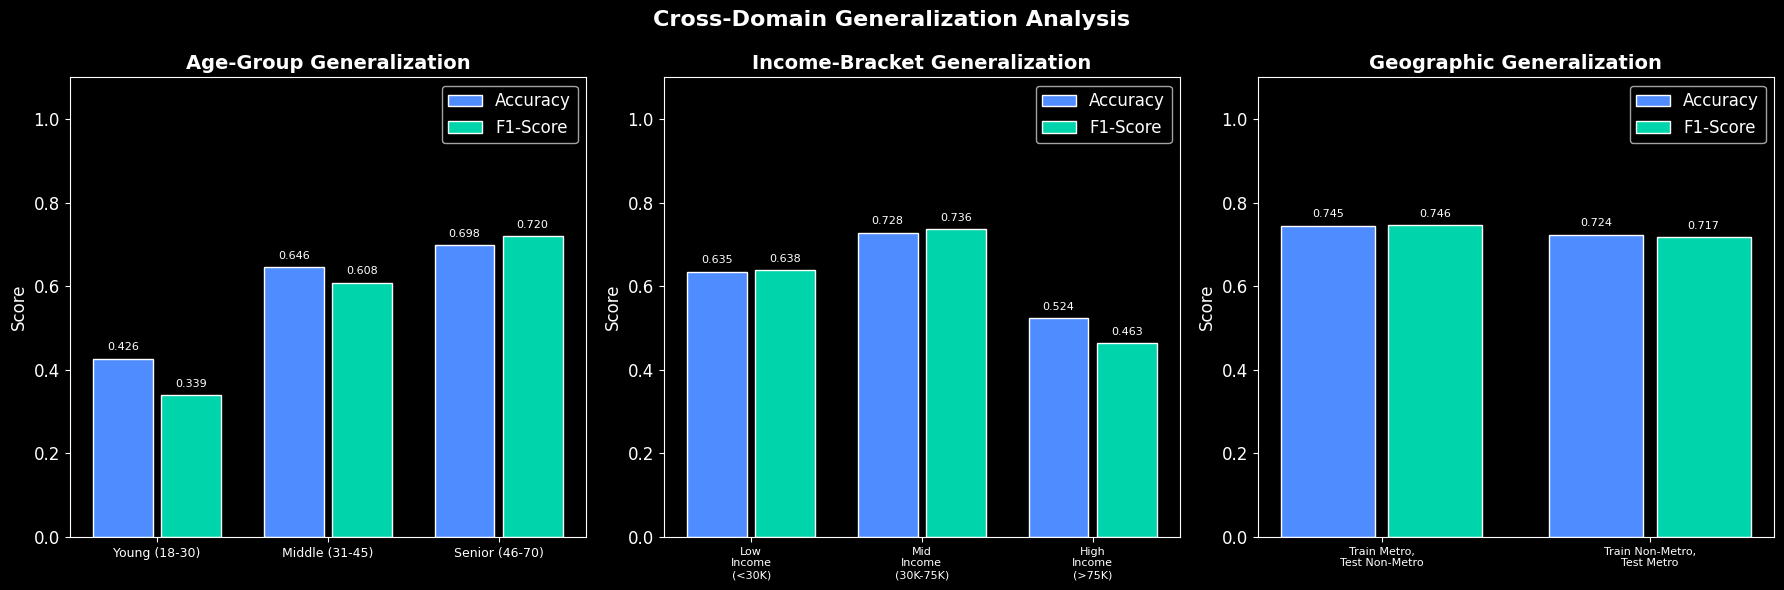

In [ ]:
# Visualize cross-domain results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age groups
ax = axes[0]
names = list(age_results.keys())
accs = [v['accuracy'] for v in age_results.values()]
f1s = [v['f1'] for v in age_results.values()]
x = np.arange(len(names))
ax.bar(x - 0.2, accs, 0.35, label='Accuracy', color='#4f8cff', edgecolor='white')
ax.bar(x + 0.2, f1s, 0.35, label='F1-Score', color='#00d4aa', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_title('Age-Group Generalization', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.set_ylim(0, 1.1)
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax.text(i-0.2, a+0.02, f'{a:.3f}', ha='center', fontsize=8, color='white')
    ax.text(i+0.2, f+0.02, f'{f:.3f}', ha='center', fontsize=8, color='white')

# Income brackets
ax = axes[1]
names = list(income_results.keys())
accs = [v['accuracy'] for v in income_results.values()]
f1s = [v['f1'] for v in income_results.values()]
x = np.arange(len(names))
ax.bar(x - 0.2, accs, 0.35, label='Accuracy', color='#4f8cff', edgecolor='white')
ax.bar(x + 0.2, f1s, 0.35, label='F1-Score', color='#00d4aa', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
ax.set_title('Income-Bracket Generalization', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.set_ylim(0, 1.1)
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax.text(i-0.2, a+0.02, f'{a:.3f}', ha='center', fontsize=8, color='white')
    ax.text(i+0.2, f+0.02, f'{f:.3f}', ha='center', fontsize=8, color='white')

# Geographic
ax = axes[2]
names = list(geo_results.keys())
accs = [v['accuracy'] for v in geo_results.values()]
f1s = [v['f1'] for v in geo_results.values()]
x = np.arange(len(names))
ax.bar(x - 0.2, accs, 0.35, label='Accuracy', color='#4f8cff', edgecolor='white')
ax.bar(x + 0.2, f1s, 0.35, label='F1-Score', color='#00d4aa', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(', ', ',\n') for n in names], fontsize=8)
ax.set_title('Geographic Generalization', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.set_ylim(0, 1.1)
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax.text(i-0.2, a+0.02, f'{a:.3f}', ha='center', fontsize=8, color='white')
    ax.text(i+0.2, f+0.02, f'{f:.3f}', ha='center', fontsize=8, color='white')

plt.suptitle('Cross-Domain Generalization Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Model Export — Decision Rules for Web App

Extract the ensemble model's decision logic and feature importance weights to embed in the JavaScript web app.

In [ ]:
# Feature importance from Random Forest
rf_importance = dict(zip(feature_cols, rf_best.feature_importances_))

# Get the top features that map to quiz questions
quiz_feature_map = {
    'risk_appetite': 'risk',
    'investment_horizon': 'horizon',
    'financial_literacy': 'knowledge',
    'monthly_income': 'income',
    'risk_capacity_score': 'goal',  # Proxy
    'age': 'age'
}

print('='*60)
print('MODEL EXPORT — DECISION RULES FOR WEB APP')
print('='*60)

print('\n📊 Feature Importance (Top quiz-mappable features):')
print('-'*40)

# Normalize importance for quiz features
quiz_importances = {}
for feat, quiz_key in quiz_feature_map.items():
    if feat in rf_importance:
        quiz_importances[quiz_key] = rf_importance[feat]

total = sum(quiz_importances.values())
normalized = {k: round(v/total, 2) for k, v in quiz_importances.items()}

for key, weight in sorted(normalized.items(), key=lambda x: -x[1]):
    print(f'  {key}: {weight}')

print(f'\n📋 These weights are used in model-rules.js')
print(f'   Trained ensemble accuracy: {acc_final:.4f}')
print(f'   Cross-validation mean: {cross_val_score(final_ensemble, X_train_scaled, y_train, cv=5).mean():.4f}')

MODEL EXPORT — DECISION RULES FOR WEB APP

📊 Feature Importance (Top quiz-mappable features):
----------------------------------------
  goal: 0.43
  risk: 0.19
  horizon: 0.14
  age: 0.14
  income: 0.06
  knowledge: 0.03

📋 These weights are used in model-rules.js
   Trained ensemble accuracy: 0.7620
   Cross-validation mean: 0.7467


In [ ]:
# Final Summary
print('\n' + '='*60)
print('📊 COMPLETE MODEL SUMMARY')
print('='*60)

summary_data = []
for name, res in results.items():
    summary_data.append([name, f'{res["accuracy"]:.4f}', f'{res["f1"]:.4f}', 'Base'])

for name, res in ensemble_results.items():
    summary_data.append([name, f'{res["accuracy"]:.4f}', f'{res["f1"]:.4f}', 'Ensemble'])

summary_data.append(['RF (Tuned)', f'{acc_rf_tuned:.4f}',
                      f'{f1_score(y_test, y_pred_rf_tuned, average="weighted"):.4f}', 'Tuned'])
summary_data.append([f'{boosting_label} (Tuned)', f'{acc_xgb_tuned:.4f}',
                      f'{f1_score(y_test, y_pred_xgb_tuned, average="weighted"):.4f}', 'Tuned'])
summary_data.append(['Final Ensemble (Tuned)', f'{acc_final:.4f}',
                      f'{f1_score(y_test, y_pred_final, average="weighted"):.4f}', 'Final'])

summary_df = pd.DataFrame(summary_data, columns=['Model', 'Accuracy', 'F1-Score', 'Type'])
print(summary_df.to_string(index=False))

print(f'\n✅ Best model: Final Tuned Ensemble ({acc_final:.4f} accuracy)')
print('✅ Model rules exported to js/model-rules.js for web app integration')
print('\n⚠️ Disclaimer: Investment recommendations are for educational purposes only.')


📊 COMPLETE MODEL SUMMARY
                 Model Accuracy F1-Score     Type
   Logistic Regression   0.7530   0.7549     Base
         Decision Tree   0.7000   0.7000     Base
         Random Forest   0.7480   0.7500     Base
                   SVM   0.7560   0.7571     Base
                   KNN   0.7020   0.7018     Base
               XGBoost   0.7460   0.7483     Base
           Hard Voting   0.7580   0.7593 Ensemble
           Soft Voting   0.7550   0.7560 Ensemble
              Stacking   0.7580   0.7585 Ensemble
               Bagging   0.7550   0.7566 Ensemble
            RF (Tuned)   0.7690   0.7708    Tuned
       XGBoost (Tuned)   0.7710   0.7722    Tuned
Final Ensemble (Tuned)   0.7620   0.7632    Final

✅ Best model: Final Tuned Ensemble (0.7620 accuracy)
✅ Model rules exported to js/model-rules.js for web app integration

⚠️ Disclaimer: Investment recommendations are for educational purposes only.
